# Comprehensive Pose Visualization Notebook

This notebook provides comprehensive visualization tools for pose estimation results, including:
1. Wholebody hand bounding boxes from pose estimation
2. EfficientTAM tracked bounding boxes
3. 2D hand pose visualizations (without body)
4. 3D hand pose visualizations with dynamic limits

The notebook is designed to process multiple data collections in batch mode.

## Setup and Imports

In [1]:
import os
import cv2
import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

# Import helper functions
from helpers.camera import load_camera_params, project_points_safe
from helpers.pose_visualization import draw_pose, visualize_poses
from helpers.plotting import pose2video
from helpers.definitions import *

print("All imports successful!")

All imports successful!


## Configuration

Specify the data collections you want to visualize and configure output settings.

In [2]:
# List of data collections to process
data_collections = [
    'cha/cha3'
]

# Video configuration
fps = 30.0
resolution = (960, 540)  # Processing resolution
original_resolution = (3840, 2160)  # Original video resolution

# Visualization settings
HAND_KPT_THRESHOLD = 0.1  # Hand keypoint confidence threshold
SHOW_BODY = False  # Do not show body in hand pose visualizations
BBOX_COLOR = (0, 255, 0)  # Green for bounding boxes
BBOX_THICKNESS = 2

# Output directory for visualizations
vis_output_base = 'visualizations'
os.makedirs(vis_output_base, exist_ok=True)

print(f"Configured to process {len(data_collections)} data collections")
print(f"Output directory: {vis_output_base}")

Configured to process 1 data collections
Output directory: visualizations


## Helper Functions

In [3]:
def load_wholebody_hand_bboxes(bbox_file):
    """
    Load wholebody hand bounding boxes from text file.
    
    Format: frame_idx x1 y1 x2 y2 conf_left x1 y1 x2 y2 conf_right
    First bbox is always left hand, second is always right hand.
    
    Returns:
        Dictionary mapping frame_idx to list of (bbox, hand_id, confidence) tuples
    """
    bboxes = {}
    
    if not os.path.exists(bbox_file):
        print(f"Bounding box file not found: {bbox_file}")
        return bboxes
    
    with open(bbox_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 11:  # frame_idx + 5 values for left hand + 5 values for right hand
                frame_idx = int(parts[0])
                
                # Left hand (hand_id = 0): x1, y1, x2, y2, conf
                left_x1, left_y1, left_x2, left_y2 = map(float, parts[1:5])
                left_conf = float(parts[5])
                
                # Right hand (hand_id = 1): x1, y1, x2, y2, conf
                right_x1, right_y1, right_x2, right_y2 = map(float, parts[6:10])
                right_conf = float(parts[10])
                
                if frame_idx not in bboxes:
                    bboxes[frame_idx] = []
                
                # Add left hand bbox with hand_id=0
                bboxes[frame_idx].append(((left_x1, left_y1, left_x2, left_y2), 0, left_conf))
                
                # Add right hand bbox with hand_id=1
                bboxes[frame_idx].append(((right_x1, right_y1, right_x2, right_y2), 1, right_conf))
    
    return bboxes

def load_tracked_bboxes(pickle_file):
    """
    Load tracked bounding boxes from pickle file.
    
    Returns:
        Dictionary mapping frame_idx to dict of {hand_id: bbox}
    """
    if not os.path.exists(pickle_file):
        print(f"Tracked bboxes file not found: {pickle_file}")
        return {}
    
    with open(pickle_file, 'rb') as f:
        tracks = pickle.load(f)
    
    return tracks

def draw_bboxes_on_frame(frame, bboxes, color=(0, 255, 0), thickness=2, show_labels=True, show_confidence=True):
    """
    Draw bounding boxes on frame.
    
    Args:
        frame: Input image
        bboxes: List of (bbox, hand_id, confidence) tuples or dict of {hand_id: bbox}
        color: BGR color tuple
        thickness: Line thickness
        show_labels: Whether to show hand ID labels
        show_confidence: Whether to show confidence scores
    """
    vis_frame = frame.copy()
    
    # Handle different bbox formats
    if isinstance(bboxes, dict):
        # Format: {hand_id: bbox}
        for hand_id, bbox in bboxes.items():
            if len(bbox) >= 4:
                x1, y1, x2, y2 = map(int, bbox[:4])
                cv2.rectangle(vis_frame, (x1, y1), (x2, y2), color, thickness)
                
                if show_labels:
                    hand_label = 'Left' if hand_id == 0 else 'Right'
                    label = f'Hand {hand_id} ({hand_label})'
                    cv2.putText(vis_frame, label, (x1, y1-10), 
                              cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    elif isinstance(bboxes, list):
        # Format: [(bbox, hand_id, confidence), ...]
        for item in bboxes:
            if len(item) == 3:
                bbox, hand_id, conf = item
            elif len(item) == 2:
                bbox, hand_id = item
                conf = None
            else:
                continue
                
            if len(bbox) >= 4:
                x1, y1, x2, y2 = map(int, bbox[:4])
                cv2.rectangle(vis_frame, (x1, y1), (x2, y2), color, thickness)
                
                if show_labels:
                    hand_label = 'Left' if hand_id == 0 else 'Right'
                    if conf is not None and show_confidence:
                        label = f'{hand_label}, conf: {round(100*conf, 1)}%'
                    else:
                        label = f'Hand {hand_id} ({hand_label})'
                    
                    # Position label above the box
                    cv2.putText(vis_frame, label, (x1 - 30, y1 - 30), 
                              cv2.FONT_HERSHEY_PLAIN, 2, color, 2)
    
    return vis_frame

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 1. Visualize Wholebody Hand Bounding Boxes

Create videos showing the bounding boxes detected from wholebody pose estimation.

In [4]:
def create_wholebody_bbox_videos(data_collection, output_dir):
    """
    Create videos visualizing wholebody hand bounding boxes.
    """
    print(f"\n{'='*60}")
    print(f"Creating wholebody bbox videos for: {data_collection}")
    print(f"{'='*60}\n")
    
    input_dir = f'inputs/{data_collection}'
    bbox_dir = f'outputs/{data_collection}'
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all video files
    video_files = [f for f in os.listdir(input_dir) if f.endswith('.MP4') or f.endswith('.mp4')]
    
    for video_file in tqdm(video_files, desc="Processing videos"):
        video_name = os.path.splitext(video_file)[0]
        video_path = os.path.join(input_dir, video_file)
        bbox_file = os.path.join(bbox_dir, f'{video_name}_wholebody_hands.txt')
        output_path = os.path.join(output_dir, f'{video_name}_wholebody_bboxes.mp4')
        
        # Skip if output already exists
        if os.path.exists(output_path):
            print(f"  Skipping {video_name} (already exists)")
            continue
        
        # Load bounding boxes
        bboxes = load_wholebody_hand_bboxes(bbox_file)
        
        if not bboxes:
            print(f"  No bounding boxes found for {video_name}")
            continue
        
        # Open video
        cap = cv2.VideoCapture(video_path)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        
        # Setup video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            # Draw bounding boxes for this frame
            if frame_idx in bboxes:
                frame = draw_bboxes_on_frame(frame, bboxes[frame_idx], 
                                            color=(255, 255, 0), thickness=2)
            
            out.write(frame)
            frame_idx += 1
        
        cap.release()
        out.release()
        
        print(f"  ✓ Created: {output_path}")

# Process all data collections
for data_collection in data_collections:
    output_dir = os.path.join(vis_output_base, data_collection, 'wholebody_bboxes')
    create_wholebody_bbox_videos(data_collection, output_dir)

print("\n✓ Wholebody bbox videos completed!")


Creating wholebody bbox videos for: cha/cha3



Processing videos: 100%|██████████| 12/12 [00:00<00:00, 880.57it/s]

  Skipping gopro10_synced_cut (already exists)
  Skipping gopro11_synced_cut (already exists)
  Skipping gopro12_synced_cut (already exists)
Bounding box file not found: outputs/cha/cha3\gopro1_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro1_synced_cut
Bounding box file not found: outputs/cha/cha3\gopro2_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro2_synced_cut
Bounding box file not found: outputs/cha/cha3\gopro3_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro3_synced_cut
Bounding box file not found: outputs/cha/cha3\gopro4_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro4_synced_cut
  Skipping gopro5_synced_cut (already exists)
  Skipping gopro6_synced_cut (already exists)
  Skipping gopro7_synced_cut (already exists)
  Skipping gopro8_synced_cut (already exists)
  Skipping gopro9_synced_cut (already exists)

✓ Wholebody bbox videos completed!


## 2. Visualize EfficientTAM Tracked Bounding Boxes

Create videos showing the tracked bounding boxes from EfficientTAM.

In [5]:
def create_tracked_bbox_videos(data_collection, output_dir):
    """
    Create videos visualizing EfficientTAM tracked bounding boxes.
    Uses hand_id_mapping to determine left/right hand for each tracked ID.
    """
    print(f"\n{'='*60}")
    print(f"Creating tracked bbox videos for: {data_collection}")
    print(f"{'='*60}\n")
    
    input_dir = f'inputs/{data_collection}'
    tracks_dir = f'outputs/{data_collection}'
    hand_id_map_path = os.path.join(f'output_3d/{data_collection}', 'hand_id_mapping.pkl')
    
    # Load hand_id_mapping if available
    hand_id_mapping = None
    if os.path.exists(hand_id_map_path):
        with open(hand_id_map_path, 'rb') as f:
            hand_id_mapping = pickle.load(f)
    else:
        print(f"  Warning: hand_id_mapping.pkl not found for {data_collection}. Using default hand_id labeling.")
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all video files
    video_files = [f for f in os.listdir(input_dir) if f.endswith('.MP4') or f.endswith('.mp4')]
    
    for video_file in tqdm(video_files, desc="Processing videos"):
        video_name = os.path.splitext(video_file)[0]
        video_path = os.path.join(input_dir, video_file)
        tracks_file = os.path.join(tracks_dir, f'tracked_bboxes_{video_name}.pkl')
        output_path = os.path.join(output_dir, f'{video_name}_tracked_bboxes.mp4')
        
        # Skip if output already exists
        if os.path.exists(output_path):
            print(f"  Skipping {video_name} (already exists)")
            continue
        
        # Load tracked bounding boxes
        tracks = load_tracked_bboxes(tracks_file)
        
        if not tracks:
            print(f"  No tracked bboxes found for {video_name}")
            continue
        
        # Open video
        cap = cv2.VideoCapture(video_path)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        
        # Setup video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            # Draw tracked bounding boxes for this frame
            if frame_idx in tracks:
                # Remap hand IDs using hand_id_mapping if available
                mapped_bboxes = {}
                for track_id, bbox in tracks[frame_idx].items():
                    if hand_id_mapping and track_id in hand_id_mapping:
                        hand_side = hand_id_mapping[track_id]  # 0=left, 1=right
                    else:
                        hand_side = track_id  # fallback: use track_id as hand_id
                    mapped_bboxes[hand_side] = bbox
                frame = draw_bboxes_on_frame(frame, mapped_bboxes, 
                                            color=(255, 0, 0), thickness=2)  # Blue for tracked
            
            out.write(frame)
            frame_idx += 1
        
        cap.release()
        out.release()
        
        print(f"  ✓ Created: {output_path}")

# Process all data collections
for data_collection in data_collections:
    output_dir = os.path.join(vis_output_base, data_collection, 'tracked_bboxes')
    create_tracked_bbox_videos(data_collection, output_dir)

print("\n✓ Tracked bbox videos completed!")


Creating tracked bbox videos for: cha/cha3



Processing videos: 100%|██████████| 12/12 [00:00<?, ?it/s]

  Skipping gopro10_synced_cut (already exists)
  Skipping gopro11_synced_cut (already exists)
  Skipping gopro12_synced_cut (already exists)
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro1_synced_cut.pkl
  No tracked bboxes found for gopro1_synced_cut
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro2_synced_cut.pkl
  No tracked bboxes found for gopro2_synced_cut
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro3_synced_cut.pkl
  No tracked bboxes found for gopro3_synced_cut
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro4_synced_cut.pkl
  No tracked bboxes found for gopro4_synced_cut
  Skipping gopro5_synced_cut (already exists)
  Skipping gopro6_synced_cut (already exists)
  Skipping gopro7_synced_cut (already exists)
  Skipping gopro8_synced_cut (already exists)
  Skipping gopro9_synced_cut (already exists)

✓ Tracked bbox videos completed!


## 3. Visualize 2D Hand Poses (No Body)

Create videos showing only hand poses using the visualize_poses function with body disabled.

In [6]:
def create_hand_pose_videos(data_collection, output_dir):
    """
    Create videos visualizing 2D hand poses without body.
    Loads hand poses from output_3d/{data_collection}/hand_poses_2d.npz and plots them.
    """
    print(f"\n{'='*60}")
    print(f"Creating 2D hand pose videos for: {data_collection}")
    print(f"{'='*60}\n")
    
    input_dir = f'inputs/{data_collection}'
    hand_pose_path = os.path.join(f'output_3d/{data_collection}', 'hand_poses_2d.npz')
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all video files
    video_files = [f for f in os.listdir(input_dir) if f.endswith('.MP4') or f.endswith('.mp4')]
    
    # Load 2D hand poses (dict of cam_name -> array)
    if not os.path.exists(hand_pose_path):
        print(f"  Hand pose file not found: {hand_pose_path}")
        return
    hand_pose_data = np.load(hand_pose_path, allow_pickle=True)
    hand_poses_2d = hand_pose_data['poses_2d'].item()  # dict: cam_name -> (num_frames, num_hands, num_keypoints, 3)
    
    for video_file in tqdm(video_files, desc="Processing videos"):
        video_name = os.path.splitext(video_file)[0]
        video_path = os.path.join(input_dir, video_file)
        output_path = os.path.join(output_dir, f'{video_name}_hand_poses.mp4')
        
        # Extract cam_name from video_name (assumes format 'goproX_synced_cut' or similar)
        cam_name = video_name.split('_')[0]
        if cam_name not in hand_poses_2d:
            print(f"  Camera {cam_name} not found in hand_poses_2d for {video_name}")
            continue
        poses_2d = hand_poses_2d[cam_name]
        
        # Skip if output already exists
        if os.path.exists(output_path):
            print(f"  Skipping {video_name} (already exists)")
            continue
        
        # Open video
        cap = cv2.VideoCapture(video_path)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        
        # Setup video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame_idx >= len(poses_2d):
                break
            
            # Draw hand poses for this frame
            for hand_id in range(len(poses_2d[frame_idx])):
                hand_pose = poses_2d[frame_idx][hand_id]
                # Only plot if confidence > threshold for at least one keypoint
                draw_pose(frame, hand_pose, pose_type='hand', IS_HAND_THRESHOLD=HAND_KPT_THRESHOLD)
            
            out.write(frame)
            frame_idx += 1
        
        cap.release()
        out.release()
        
        print(f"  ✓ Created: {output_path}")

# Process all data collections
for data_collection in data_collections:
    output_dir = os.path.join(vis_output_base, data_collection, 'hand_poses_2d')
    create_hand_pose_videos(data_collection, output_dir)

print("\n✓ 2D hand pose videos completed!")


Creating 2D hand pose videos for: cha/cha3



Processing videos: 100%|██████████| 12/12 [00:00<?, ?it/s]

  Skipping gopro10_synced_cut (already exists)
  Skipping gopro11_synced_cut (already exists)
  Skipping gopro12_synced_cut (already exists)
  Camera gopro1 not found in hand_poses_2d for gopro1_synced_cut
  Camera gopro2 not found in hand_poses_2d for gopro2_synced_cut
  Camera gopro3 not found in hand_poses_2d for gopro3_synced_cut
  Camera gopro4 not found in hand_poses_2d for gopro4_synced_cut
  Skipping gopro5_synced_cut (already exists)
  Skipping gopro6_synced_cut (already exists)
  Skipping gopro7_synced_cut (already exists)
  Skipping gopro8_synced_cut (already exists)
  Skipping gopro9_synced_cut (already exists)

✓ 2D hand pose videos completed!


## 4. Visualize 3D Hand Poses

Create visualizations of 3D hand poses using pose2video with render_body=False and dynamic_limits=True.

c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\matplotlib\animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(



Creating 3D hand pose videos for: cha/cha3

  Loaded bmc: (301, 42, 3)
  ✓ Created: visualizations\cha/cha3\hand_poses_3d\visualizations_bmc.mp4
  Loaded no_bmc: (300, 42, 3)


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\matplotlib\animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(
c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\matplotlib\animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


  ✓ Created: visualizations\cha/cha3\hand_poses_3d\visualizations_no_bmc.mp4
  Loaded triangulation: (300, 42, 3)
  ✓ Created: visualizations\cha/cha3\hand_poses_3d\visualizations_triangulation.mp4
  Loaded temp: (300, 42, 3)


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\matplotlib\animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


  ✓ Created: visualizations\cha/cha3\hand_poses_3d\visualizations_temp.mp4

✓ 3D hand pose videos completed!


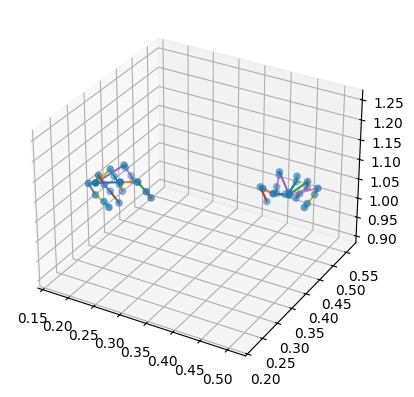

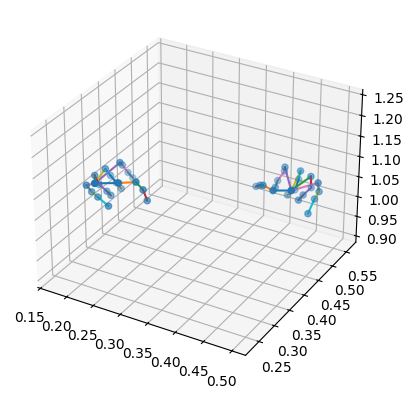

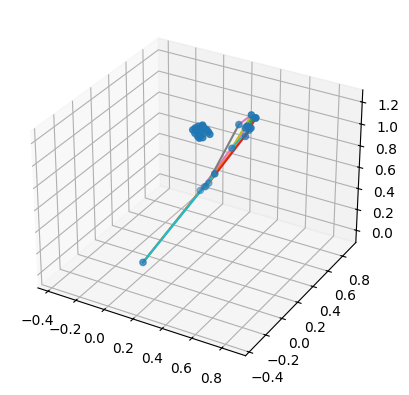

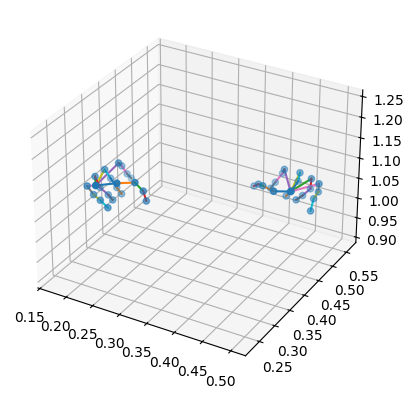

In [7]:
def create_3d_hand_pose_videos(data_collection, output_dir):
    """
    Create videos visualizing 3D hand poses.
    Uses pose2video with render_body=False and dynamic_limits=True.
    """
    print(f"\n{'='*60}")
    print(f"Creating 3D hand pose videos for: {data_collection}")
    print(f"{'='*60}\n")
    
    poses_3d_dir = f'output_3d/{data_collection}'
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Find all 3D hand pose files
    pose_files = [
        'hand_poses_3d_bmc_mapped.npz',
        'hand_poses_3d_no_bmc_mapped.npz',
        'hand_poses_3d_triangulation_mapped.npz',
        'hand_poses_3d_temp_mapped.npz'
    ]
    
    for pose_file in pose_files:
        pose_path = os.path.join(poses_3d_dir, pose_file)
        
        if not os.path.exists(pose_path):
            print(f"  Pose file not found: {pose_file}")
            continue
        
        # Extract method name from filename
        method_name = pose_file.replace('hand_poses_3d_', '').replace('_mapped.npz', '').replace('.npz', '')
        output_path = os.path.join(output_dir, f'visualizations_{method_name}.mp4')
        
        # Skip if output already exists
        if os.path.exists(output_path):
            print(f"  Skipping {method_name} (already exists)")
            continue
        
        # Load 3D hand poses
        try:
            data = np.load(pose_path, allow_pickle=True)
            hand_poses_3d = data['poses_3d']
            print(f"  Loaded {method_name}: {hand_poses_3d.shape}")
        except Exception as e:
            print(f"  Error loading {pose_file}: {e}")
            continue
        
        # Create 3D visualization using pose2video
        try:
            pose2video(
                [],
                output_dir,
                f'visualizations_{method_name}',
                hand_poses_3d,
                fps=fps,
                render_body=False,  # Only hands
                dynamic_limits=True,  # Dynamic axis limits
            )
            print(f"  ✓ Created: {output_path}")
        except Exception as e:
            print(f"  Error creating video for {method_name}: {e}")

# Process all data collections
for data_collection in data_collections:
    output_dir = os.path.join(vis_output_base, data_collection, 'hand_poses_3d')
    create_3d_hand_pose_videos(data_collection, output_dir)

print("\n✓ 3D hand pose videos completed!")

## Run All Visualizations

Execute all visualization steps for all configured data collections.

In [8]:
def run_all_visualizations():
    """
    Run all visualization pipelines for all data collections.
    """
    print("\n" + "="*80)
    print("STARTING COMPREHENSIVE POSE VISUALIZATION PIPELINE")
    print("="*80 + "\n")
    
    total_collections = len(data_collections)
    
    for idx, data_collection in enumerate(data_collections, 1):
        print(f"\n\n{'#'*80}")
        print(f"# Processing Collection {idx}/{total_collections}: {data_collection}")
        print(f"{'#'*80}\n")
        
        # 1. Wholebody bounding boxes
        try:
            output_dir = os.path.join(vis_output_base, data_collection, 'wholebody_bboxes')
            create_wholebody_bbox_videos(data_collection, output_dir)
        except Exception as e:
            print(f"ERROR in wholebody bboxes: {e}")
        
        # 2. Tracked bounding boxes
        try:
            output_dir = os.path.join(vis_output_base, data_collection, 'tracked_bboxes')
            create_tracked_bbox_videos(data_collection, output_dir)
        except Exception as e:
            print(f"ERROR in tracked bboxes: {e}")
        
        # 3. 2D hand poses
        try:
            output_dir = os.path.join(vis_output_base, data_collection, 'hand_poses_2d')
            create_hand_pose_videos(data_collection, output_dir)
        except Exception as e:
            print(f"ERROR in 2D hand poses: {e}")
        
        # 4. 3D hand poses
        try:
            output_dir = os.path.join(vis_output_base, data_collection, 'hand_poses_3d')
            create_3d_hand_pose_videos(data_collection, output_dir)
        except Exception as e:
            print(f"ERROR in 3D hand poses: {e}")
    
    print("\n\n" + "="*80)
    print("✓ ALL VISUALIZATIONS COMPLETED!")
    print("="*80)
    print(f"\nOutputs saved to: {vis_output_base}/")

# Run the complete pipeline
run_all_visualizations()


STARTING COMPREHENSIVE POSE VISUALIZATION PIPELINE



################################################################################
# Processing Collection 1/1: cha/cha3
################################################################################


Creating wholebody bbox videos for: cha/cha3



Processing videos: 100%|██████████| 12/12 [00:00<00:00, 3977.84it/s]


  Skipping gopro10_synced_cut (already exists)
  Skipping gopro11_synced_cut (already exists)
  Skipping gopro12_synced_cut (already exists)
Bounding box file not found: outputs/cha/cha3\gopro1_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro1_synced_cut
Bounding box file not found: outputs/cha/cha3\gopro2_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro2_synced_cut
Bounding box file not found: outputs/cha/cha3\gopro3_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro3_synced_cut
Bounding box file not found: outputs/cha/cha3\gopro4_synced_cut_wholebody_hands.txt
  No bounding boxes found for gopro4_synced_cut
  Skipping gopro5_synced_cut (already exists)
  Skipping gopro6_synced_cut (already exists)
  Skipping gopro7_synced_cut (already exists)
  Skipping gopro8_synced_cut (already exists)
  Skipping gopro9_synced_cut (already exists)

Creating tracked bbox videos for: cha/cha3



Processing videos: 100%|██████████| 12/12 [00:00<00:00, 2997.54it/s]


  Skipping gopro10_synced_cut (already exists)
  Skipping gopro11_synced_cut (already exists)
  Skipping gopro12_synced_cut (already exists)
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro1_synced_cut.pkl
  No tracked bboxes found for gopro1_synced_cut
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro2_synced_cut.pkl
  No tracked bboxes found for gopro2_synced_cut
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro3_synced_cut.pkl
  No tracked bboxes found for gopro3_synced_cut
Tracked bboxes file not found: outputs/cha/cha3\tracked_bboxes_gopro4_synced_cut.pkl
  No tracked bboxes found for gopro4_synced_cut
  Skipping gopro5_synced_cut (already exists)
  Skipping gopro6_synced_cut (already exists)
  Skipping gopro7_synced_cut (already exists)
  Skipping gopro8_synced_cut (already exists)
  Skipping gopro9_synced_cut (already exists)

Creating 2D hand pose videos for: cha/cha3



Processing videos: 100%|██████████| 12/12 [00:00<?, ?it/s]

  Skipping gopro10_synced_cut (already exists)
  Skipping gopro11_synced_cut (already exists)
  Skipping gopro12_synced_cut (already exists)
  Camera gopro1 not found in hand_poses_2d for gopro1_synced_cut
  Camera gopro2 not found in hand_poses_2d for gopro2_synced_cut
  Camera gopro3 not found in hand_poses_2d for gopro3_synced_cut
  Camera gopro4 not found in hand_poses_2d for gopro4_synced_cut
  Skipping gopro5_synced_cut (already exists)
  Skipping gopro6_synced_cut (already exists)
  Skipping gopro7_synced_cut (already exists)
  Skipping gopro8_synced_cut (already exists)
  Skipping gopro9_synced_cut (already exists)

Creating 3D hand pose videos for: cha/cha3

  Skipping bmc (already exists)
  Skipping no_bmc (already exists)
  Skipping triangulation (already exists)
  Skipping temp (already exists)


✓ ALL VISUALIZATIONS COMPLETED!

Outputs saved to: visualizations/


## Summary Statistics

In [9]:
def print_summary_statistics():
    """
    Print summary statistics of generated visualizations.
    """
    print("\n" + "="*80)
    print("VISUALIZATION SUMMARY")
    print("="*80 + "\n")
    
    for data_collection in data_collections:
        print(f"\nData Collection: {data_collection}")
        print("-" * 60)
        
        base_dir = os.path.join(vis_output_base, data_collection)
        
        # Count files in each subdirectory
        subdirs = ['wholebody_bboxes', 'tracked_bboxes', 'hand_poses_2d', 'hand_poses_3d']
        
        for subdir in subdirs:
            subdir_path = os.path.join(base_dir, subdir)
            if os.path.exists(subdir_path):
                files = [f for f in os.listdir(subdir_path) if f.endswith('.mp4')]
                print(f"  {subdir:20s}: {len(files):3d} videos")
            else:
                print(f"  {subdir:20s}:   0 videos (directory not found)")
    
    print("\n" + "="*80)

# Print summary
print_summary_statistics()


VISUALIZATION SUMMARY


Data Collection: cha/cha3
------------------------------------------------------------
  wholebody_bboxes    :   8 videos
  tracked_bboxes      :   8 videos
  hand_poses_2d       :   8 videos
  hand_poses_3d       :   4 videos

